In [1]:
from model_ranking import (
    load_h5,
    get_roi_slice
)
import matplotlib.pyplot as plt
import numpy as np

INFO: P [MainThread] 2025-10-21 16:13:30,923 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
V_gt_path = "/scratch/talks/data/VNC/resized_pixels/source_mitoEM_true.h5"
gt_key = "resized_labels"
raw_key = "resized_raw"

# EtoV_def_E_model_Res1

In [4]:
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/consistency/finetuned_fullslice/EtoV_def_E_model_Res1/norm_Normalize/none/predictions/source_mitoEM_true_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/consistency/finetuned_fullslice/EtoV_def_E_model_Res1/norm_Normalize/gauss_a01-012/predictions/source_mitoEM_true_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [5]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

In [6]:
nan_ids = np.where(np.isnan(EI_consis))[0]
print(len(nan_ids))

0


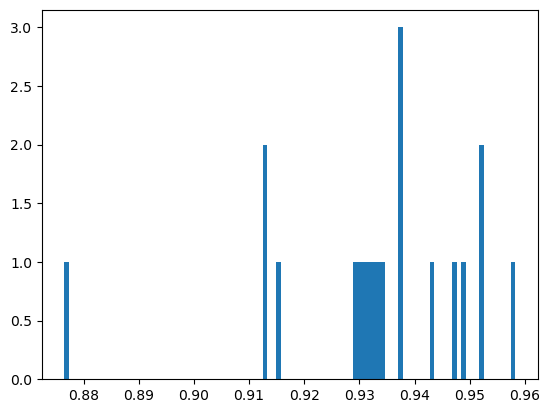

In [7]:
plt.hist(EI_consis, bins=100)
plt.show()

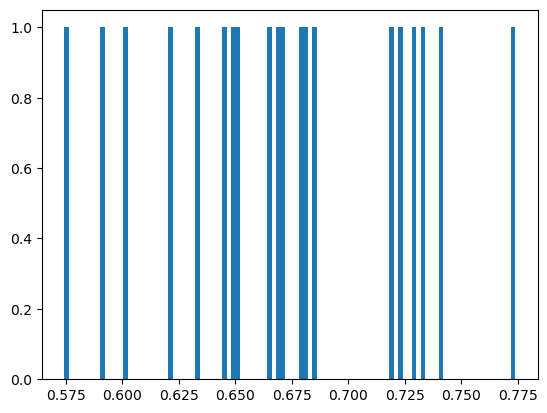

In [8]:
plt.hist(F1_scores[:, 1], bins=100)
plt.show()

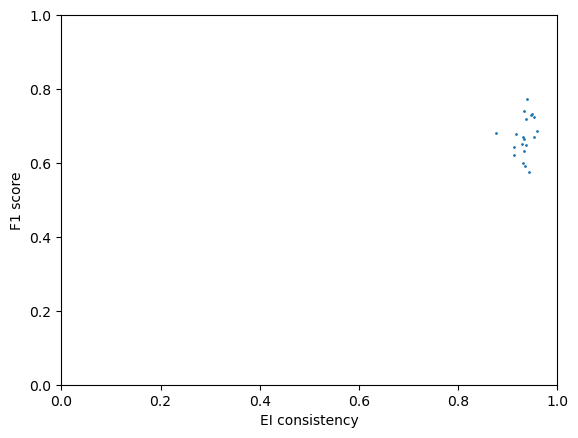

In [9]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.xlabel("EI consistency")
plt.ylabel("F1 score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

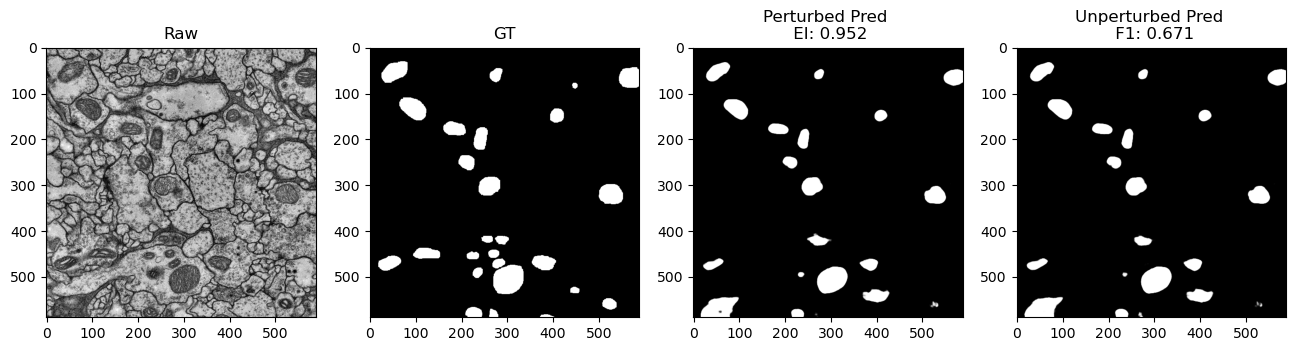

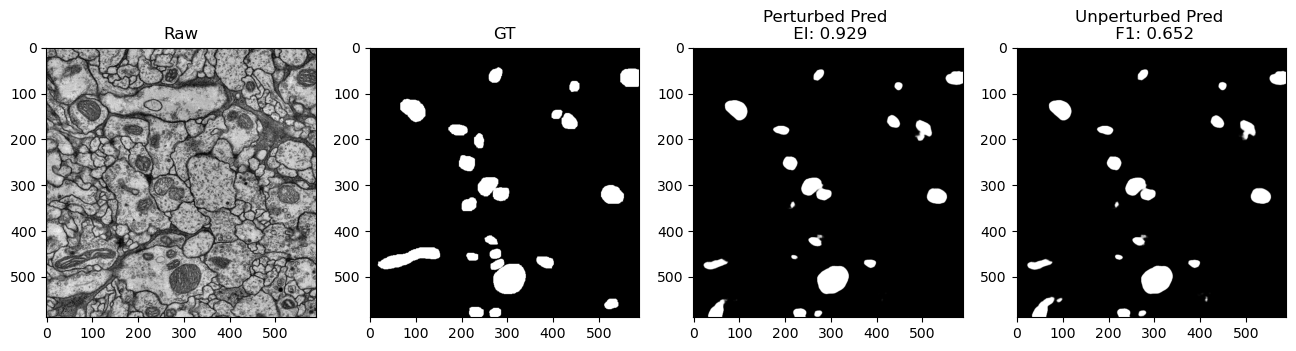

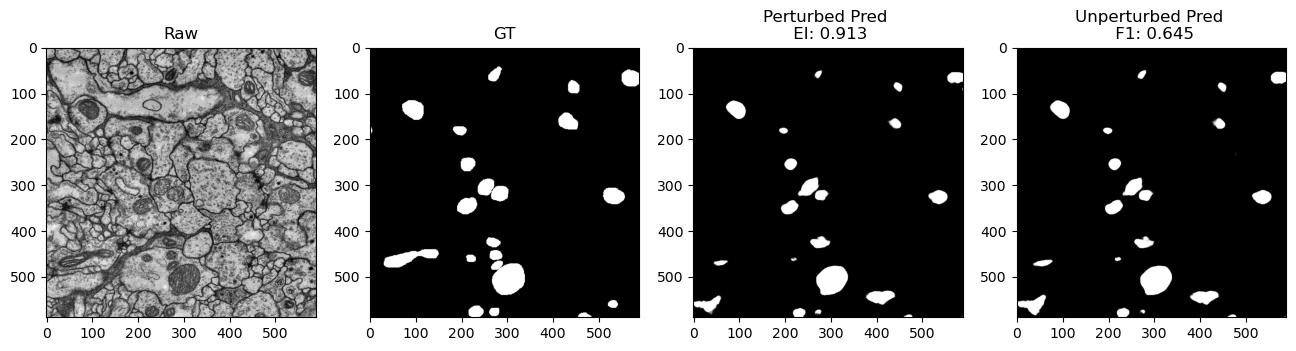

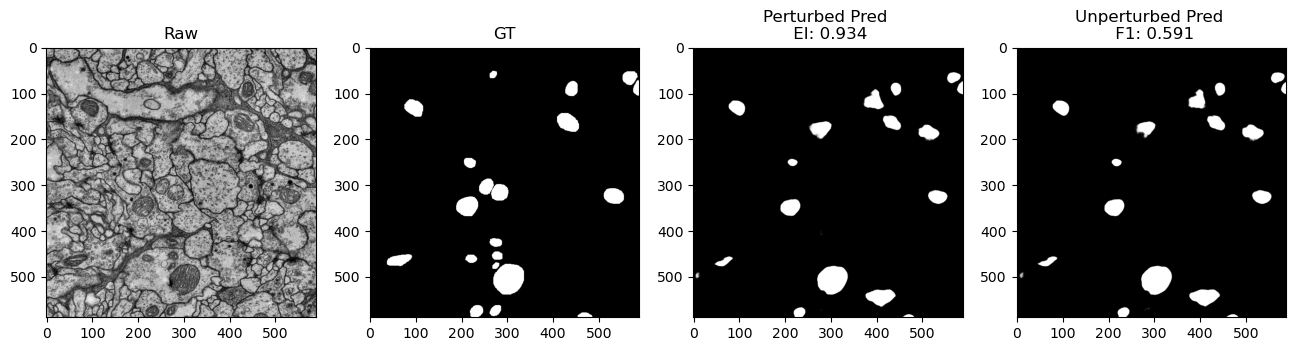

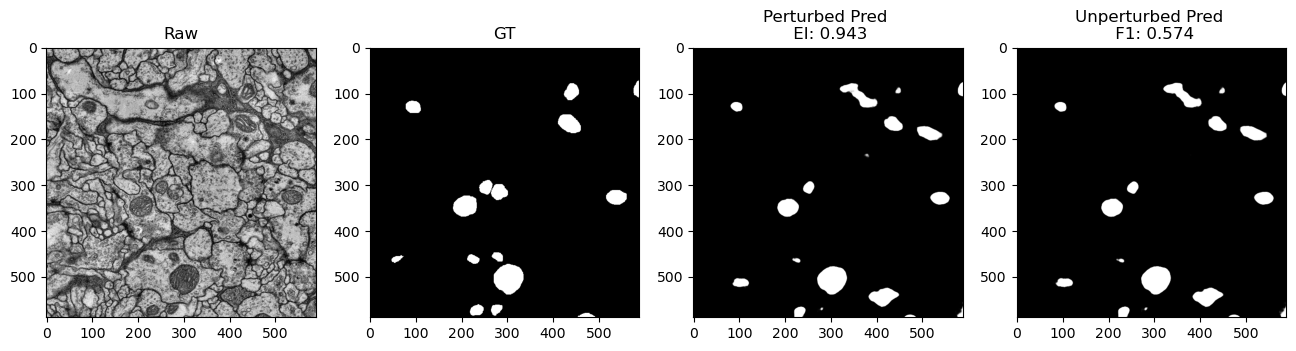

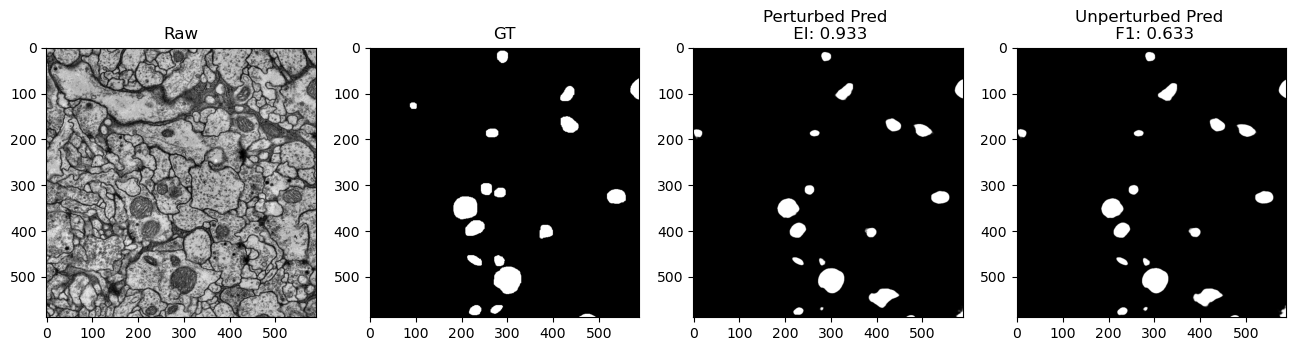

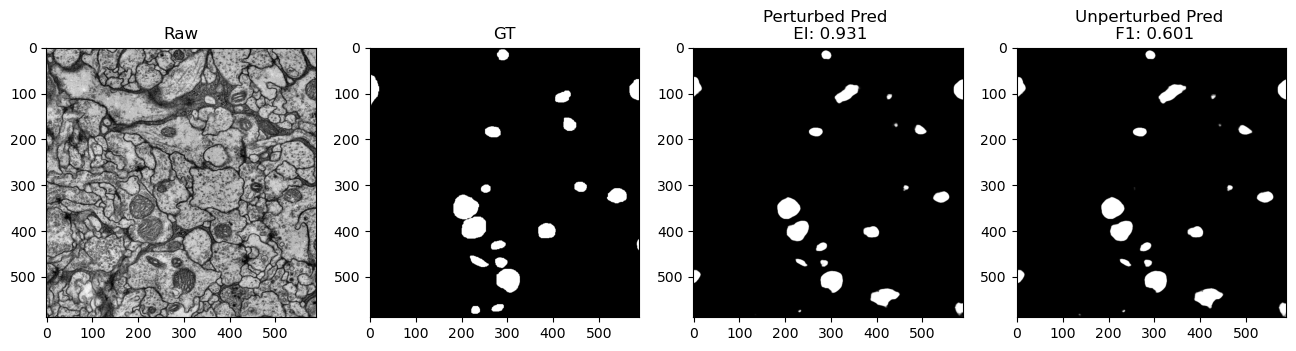

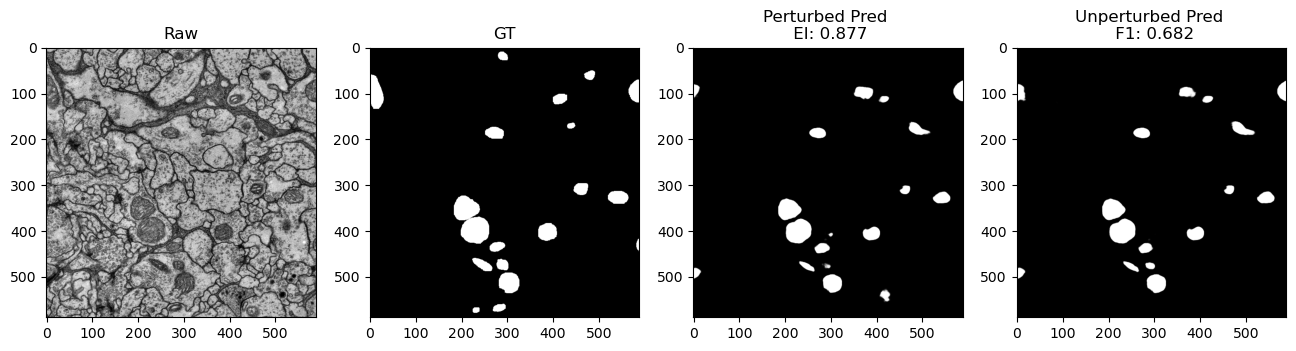

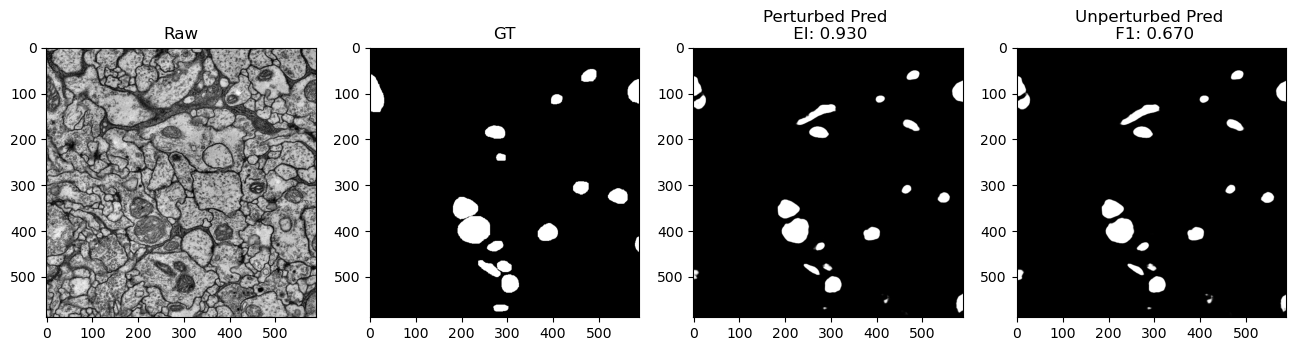

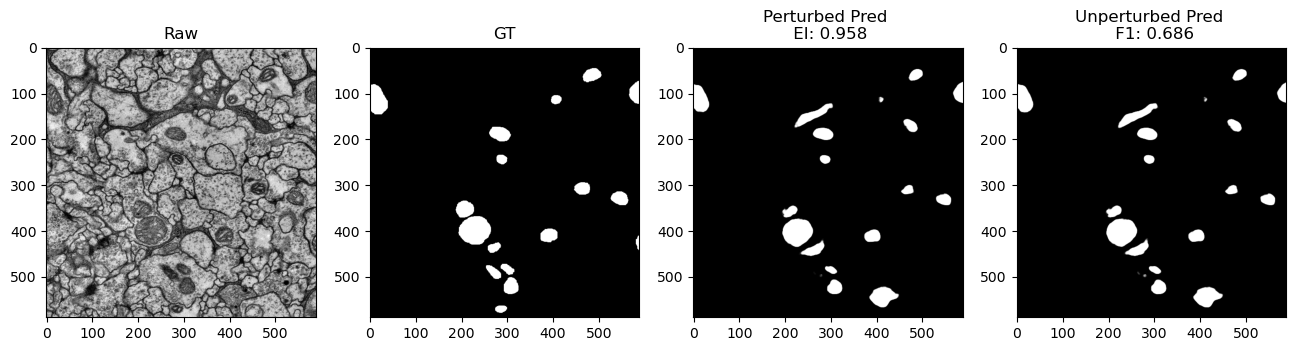

In [10]:
num_samples = 10
for i in range(num_samples):
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(V_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(V_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()

# RtoV_def_Rm_model4

In [11]:
p_path ="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_VNC_gap/consistency/finetuned_fullslice/RtoV_def_Rm_model4/norm_Normalize/gauss_a01-012/predictions/source_mitoEM_true_predictions.h5"
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_VNC_gap/consistency/finetuned_fullslice/RtoV_def_Rm_model4/norm_Normalize/none/predictions/source_mitoEM_true_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [12]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

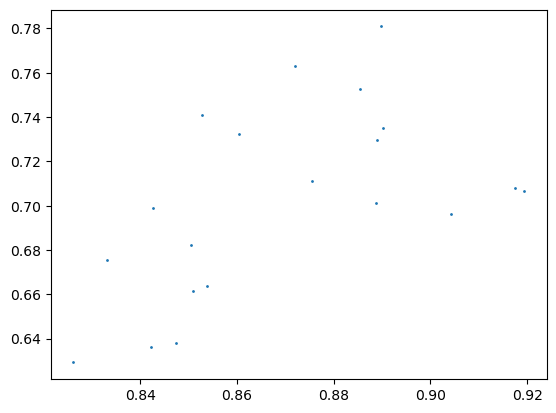

In [13]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.show()

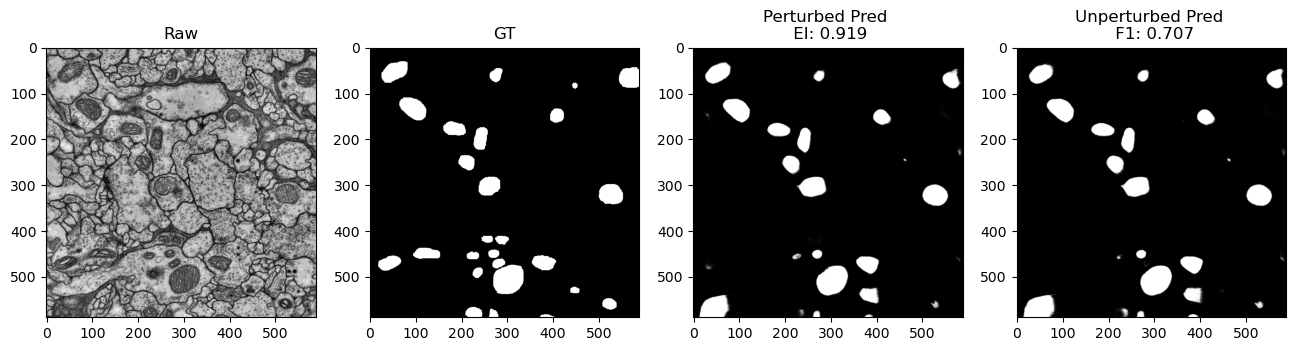

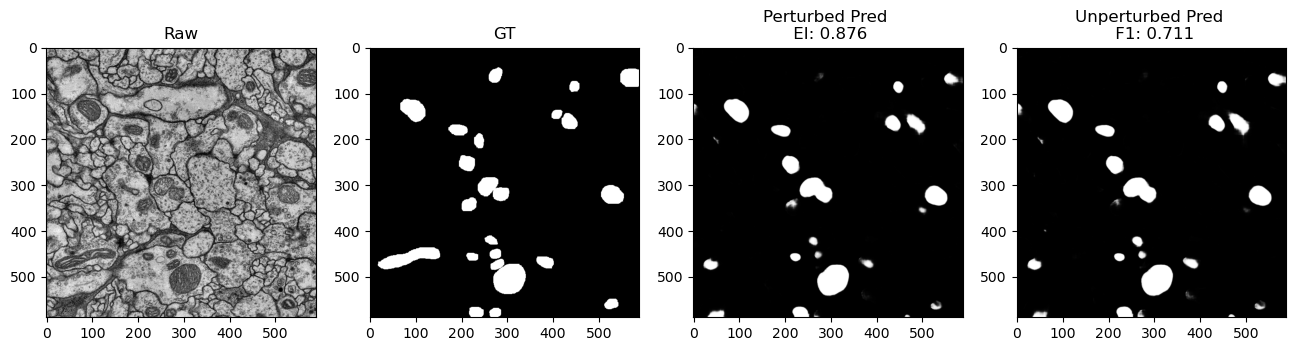

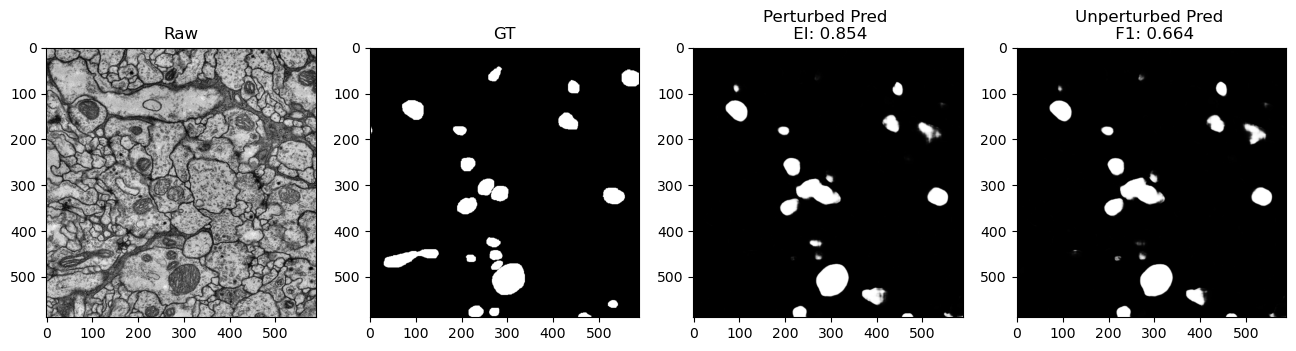

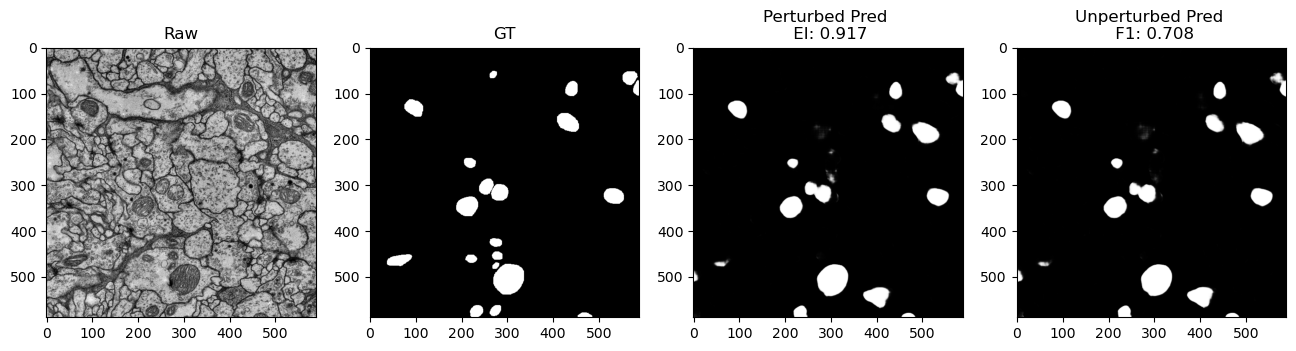

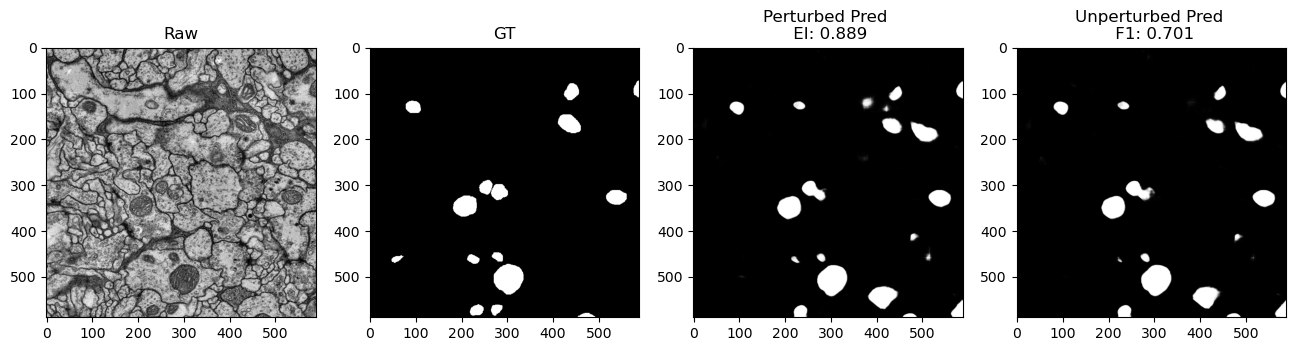

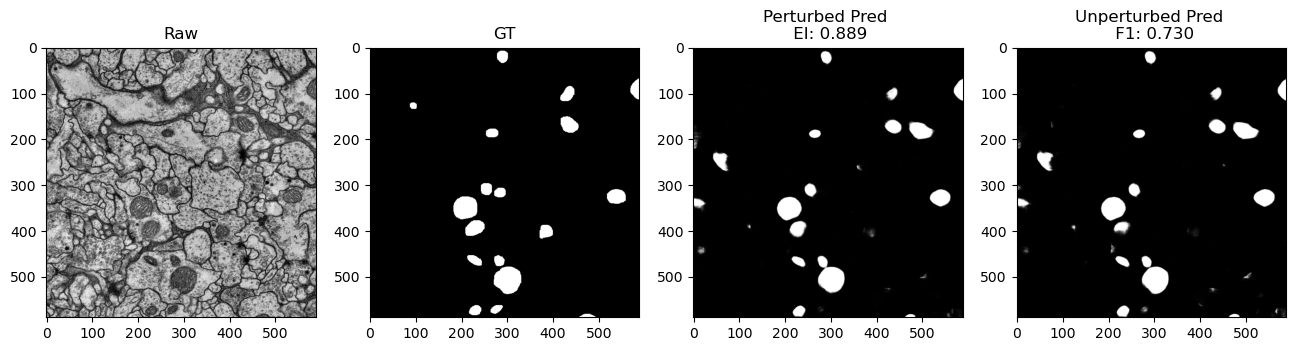

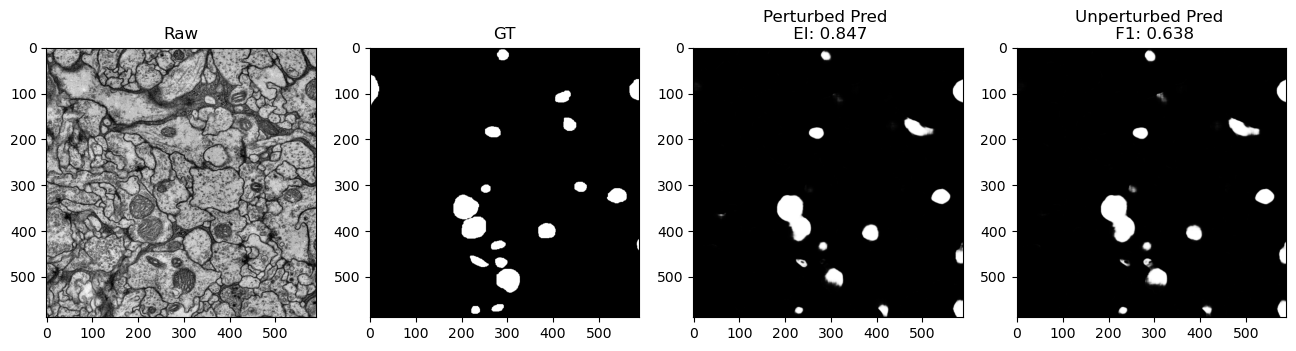

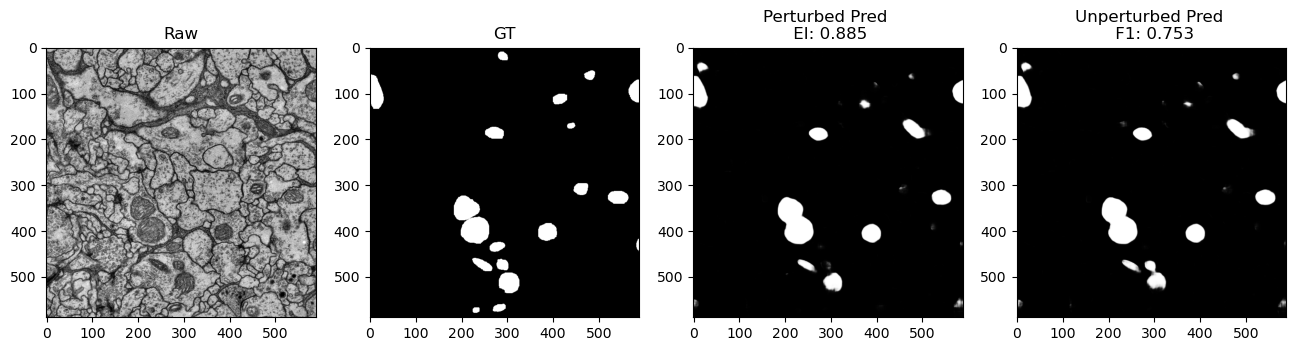

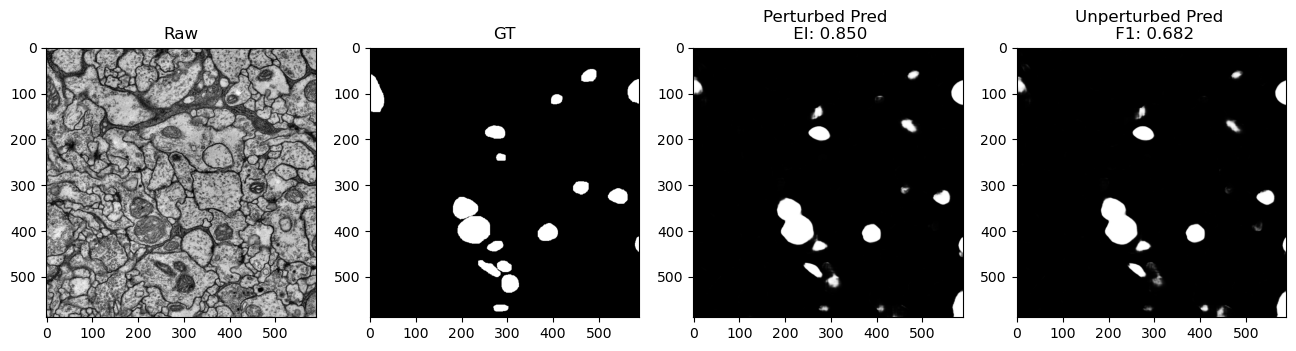

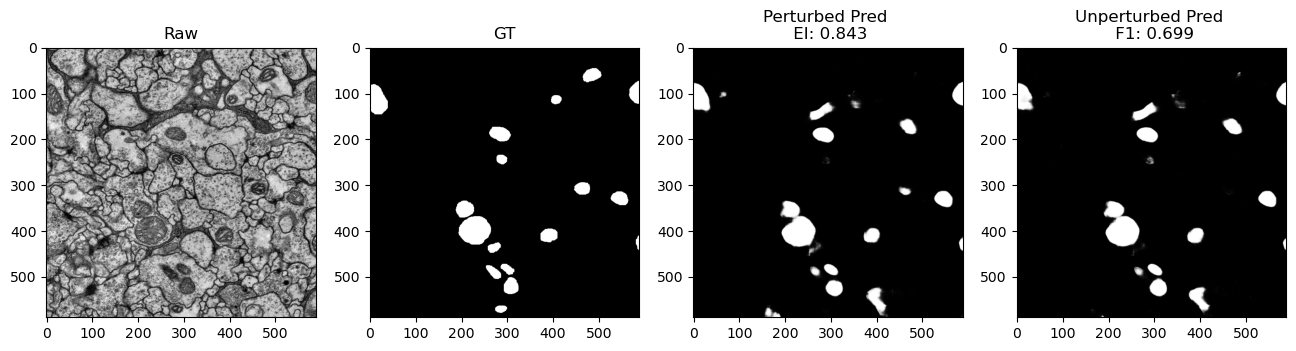

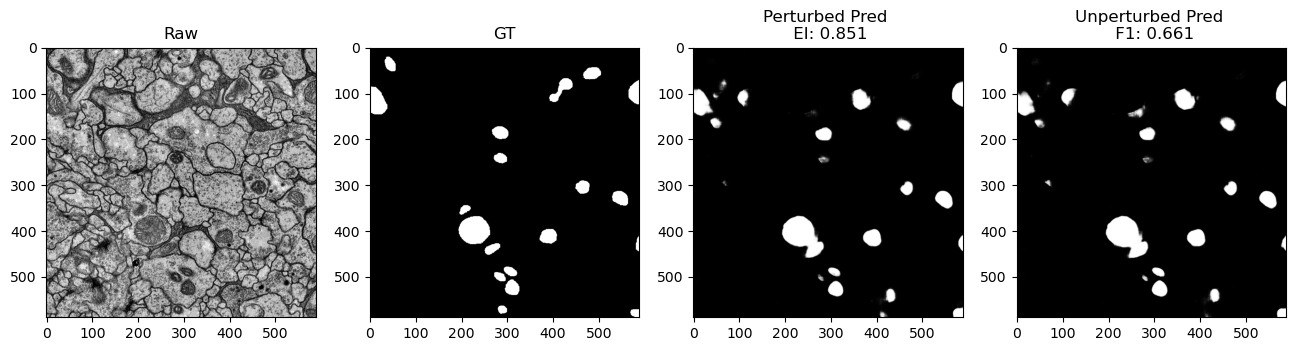

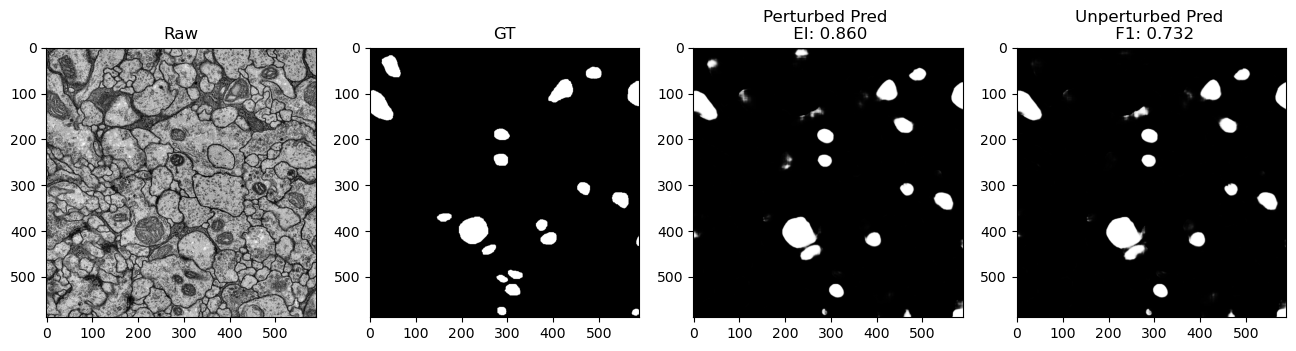

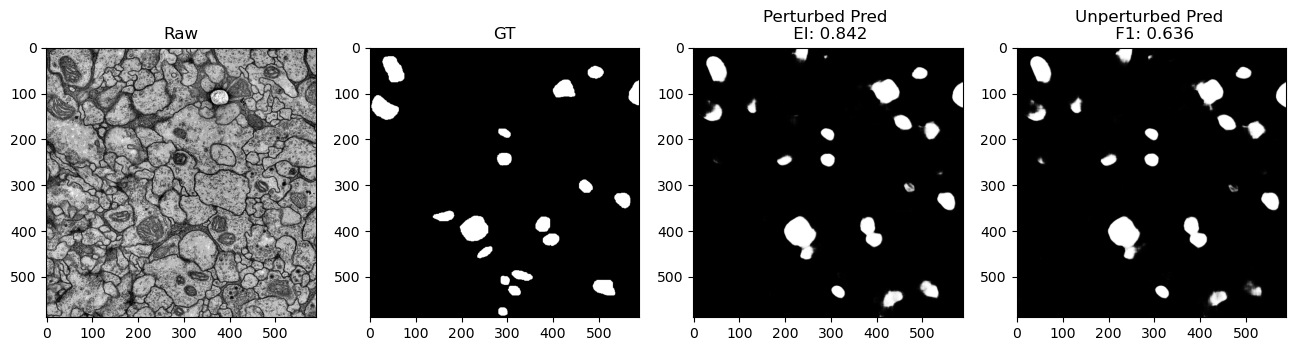

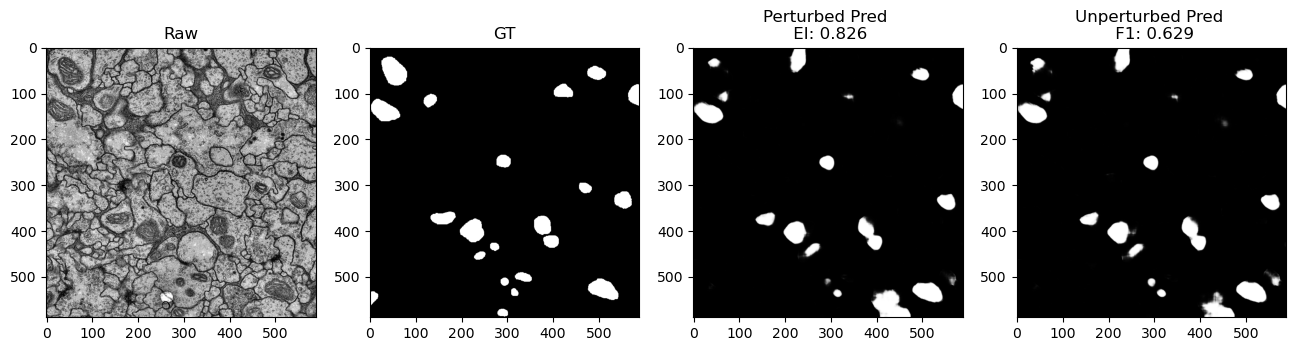

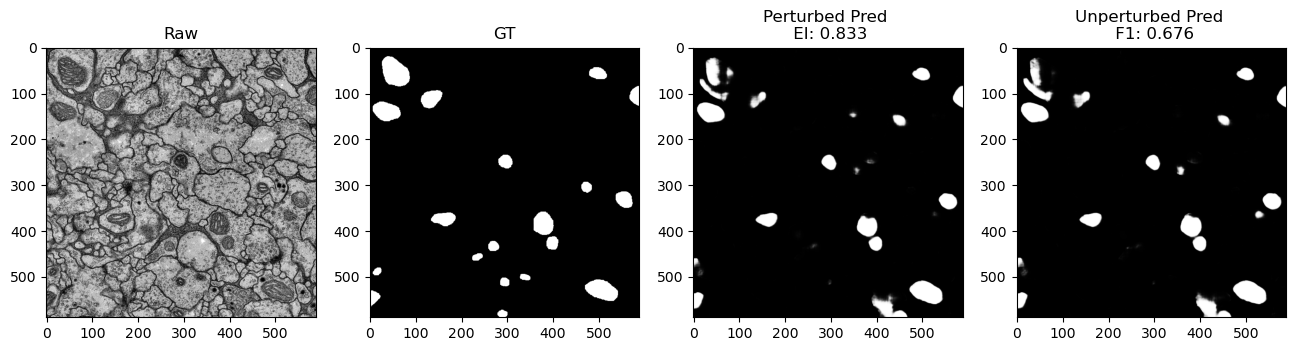

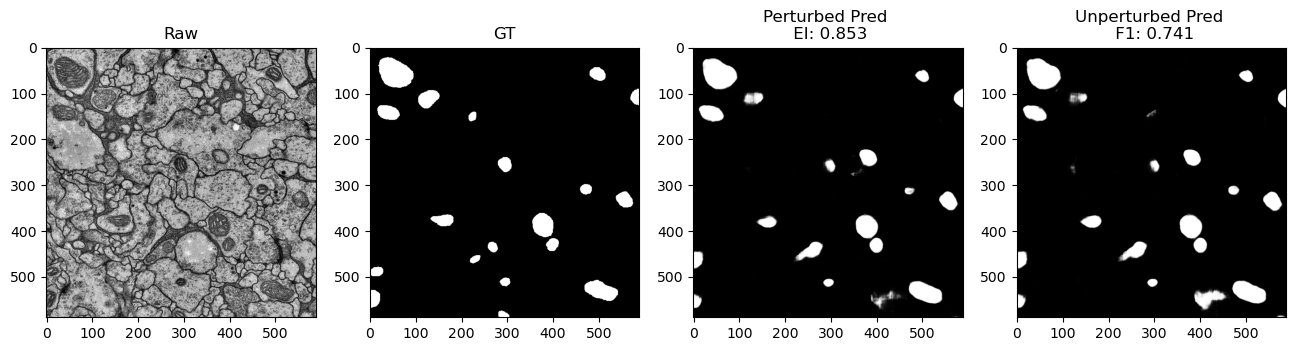

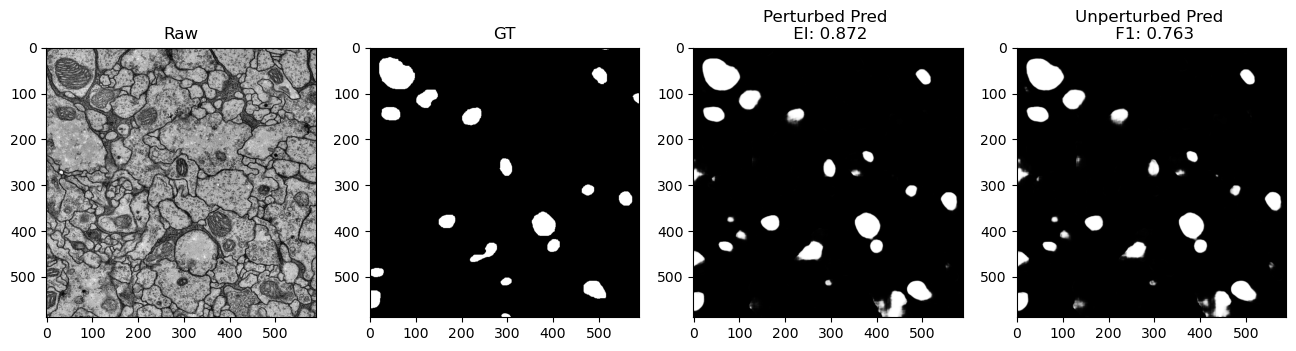

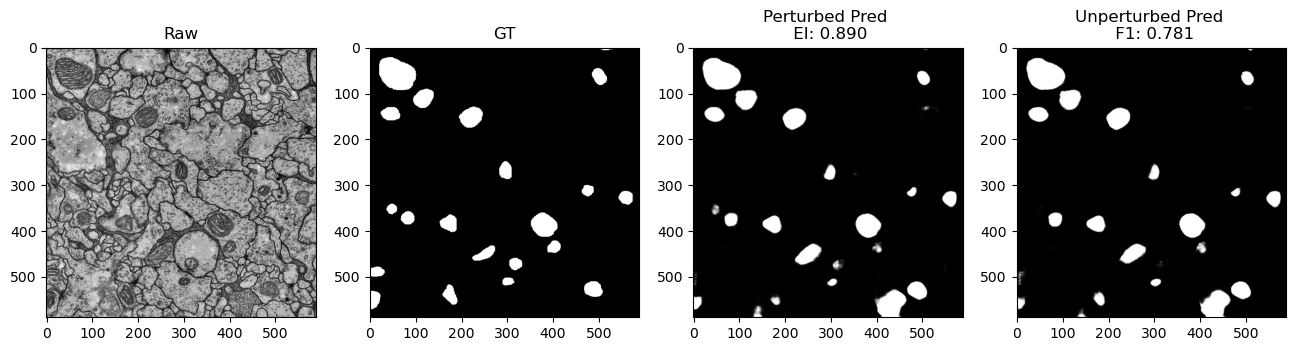

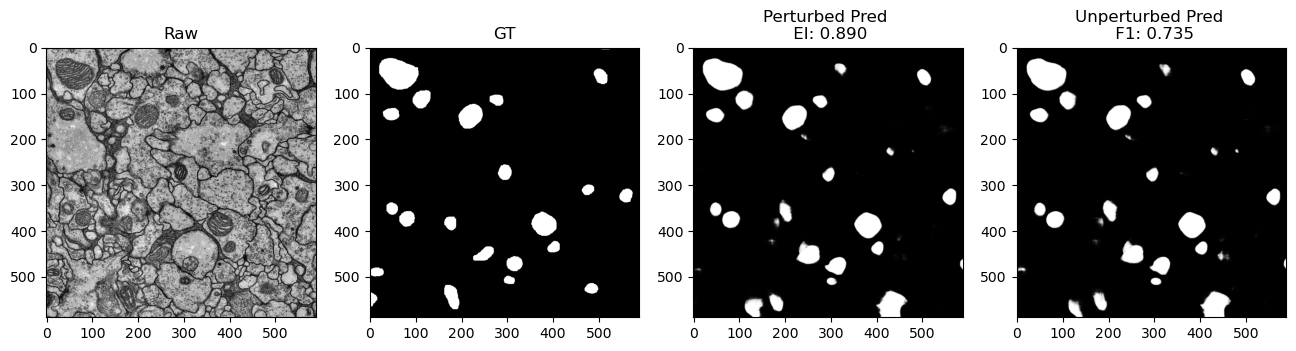

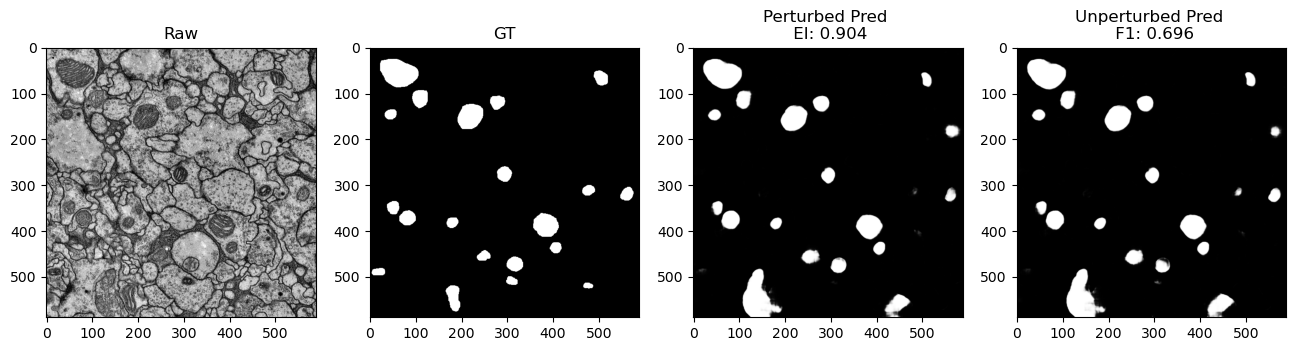

In [14]:
offset = 0
num_samples = 20
for i in range(offset, offset + num_samples):
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(V_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(V_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()

# VtoR_def_V_model2

In [16]:
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned/VtoR_def_V_model2/norm_Normalize/none/predictions/test_converted_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned/VtoR_def_V_model2/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [17]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

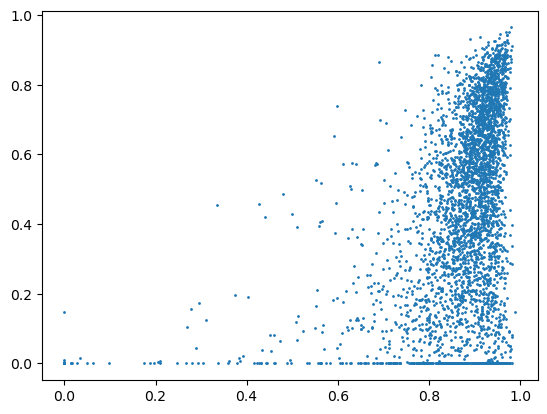

In [18]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.show()

In [19]:
zero_f1_ids = np.where(F1_scores[:, 1] == 0)[0]
print(len(zero_f1_ids))

380


In [20]:
f1_ids_not_zero = np.where(F1_scores[:, 1] != 0)[0]
print(len(f1_ids_not_zero))

3370


In [27]:
high_f1_ids = np.where(F1_scores[:, 1] > 0.85)[0]
print(len(high_f1_ids))

160


In [21]:
np.nanmedian(EI_consis)

0.9010413

In [22]:
np.nanmedian(EI_consis[f1_ids_not_zero])

0.9037818

In [23]:
low_f1_high_consis_ids = np.where((F1_scores[:, 1] < 0.2) & (F1_scores[:, 1] > 0) & (EI_consis > 0.8))[0]
print(len(low_f1_high_consis_ids))

353


In [ ]:
offset = 20
num_samples = 10
for i in high_f1_ids[offset:offset+num_samples]:
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(H_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(H_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()